# Saraga Audiovisual

**Saraga Audiovisual** is a dataset that includes new and more diverse renditions of **Carnatic vocal performances**, totaling **42 concerts** and more than **60 hours of music**.  

A major contribution of this dataset is the inclusion of **video recordings** for all concerts, allowing for a wide range of multimodal analyses. We also provide **high-quality human pose estimation data** of the musicians extracted from the video footage. Additionally, we perform benchmarking experiments for the different modalities to validate the utility of the novel collection. For more details refer to {cite}`shankar2024saraga` paper.

**Saraga Audiovisual**, along with access tools and results of our experiments, is made available for research purposes.

```{figure} ../images/gesture.png
alt: Emphasizing the diagonals.
name: emphasizing_diagonals
Adithi Prahlad performing Ananda Natana Prakasham
```


## 1.Accessing the Saraga Audiovisual Dataset  

### 1.1.Download the Dataset

The Saraga dataset is available on Zenodo. You can download it using the following link:  
[Zondo Link](https://zenodo.org/records/15102483)  

The dataset is split into multiple parts, each containing specific components:

- **`saraga_audio.zip`** – Multi-track audio files along with their corresponding mixture files.
- **`saraga_gesture.zip`** – Pose estimation files extracted from videos corresponding to each audio track.
- **`saraga_metadata.zip`** – Metadata for all the audio files.
- **`saraga_video.zip`** – Videos from three sample concerts. Due to size constraints, only these three concerts are included. For access to the full video collection, contact the dataset providers.

Visit [Zenodo](https://zenodo.org/records/15102483) and manually download the required zip files.

Alternatively, you can use `wget` to download the files directly.

> Uncomment and run the code in this section to download and unzip the dataset.

In [1]:
!wget -O "../data/saraga_audio.zip" "https://zenodo.org/records/16411600/files/saraga%20audio.zip?download=1"
!wget -O "../data/saraga_gesture.zip" "https://zenodo.org/records/16411600/files/saraga%20gesture.zip?download=1"
!wget -O "../data/saraga_metadata.zip" "https://zenodo.org/records/16411600/files/saraga%20metadata.zip?download=1"
!wget -O "../data/saraga_visual.zip" "https://zenodo.org/records/16411600/files/saraga%20visual.zip?download=1"

--2026-01-31 12:42:47--  https://zenodo.org/records/16411600/files/saraga%20audio.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.43.153, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 210885497 (201M) [application/octet-stream]
Saving to: ‘../data/saraga_audio.zip’

../data/saraga_audi 100%[===================>] 201.12M   952KB/s    in 1m 47s  

2026-01-31 12:44:37 (1.87 MB/s) - ‘../data/saraga_audio.zip’ saved [210885497/210885497]

--2026-01-31 12:44:37--  https://zenodo.org/records/16411600/files/saraga%20gesture.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 137.138.52.235, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85752194 (82M) [application/octet-stream]
Saving to: ‘../data/saraga_gesture.zip’

../data/saraga_gest 100%[=============

### 1.2. Extract the Dataset

Once the files are downloaded, extract them into a common folder.  
For that, we use `zipfile`, a Python library for handling zip files.

In [2]:
import zipfile

In [3]:
saraga_folder = "../data/saraga"
zip_files = ["../data/saraga_gesture.zip", "../data/saraga_metadata.zip", "../data/saraga_visual.zip", "../data/saraga_audio.zip"]

In [4]:
# Extract each zip file to extract path
for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(saraga_folder)
    print(f"Extracted {zip_file} to {saraga_folder}")

Extracted ../data/saraga_gesture.zip to ../data/saraga
Extracted ../data/saraga_metadata.zip to ../data/saraga
Extracted ../data/saraga_visual.zip to ../data/saraga
Extracted ../data/saraga_audio.zip to ../data/saraga


## Saraga Dataset Structure

The `saraga` folder contains four separate subfolders:

- `saraga_gesture`
- `saraga_metadata`
- `saraga_visual`
- `saraga_audio`

Each of these folders follows the same structure:
- They contain folders of concerts named after the lead vocalist.
- Each concert folder contains multiple song folders.
- Each song folder contains files related to a specific performance.


### Metadata

- **Location:** `saraga_metadata`
- Each song folder contains a `.json` file with:
  - `title`: Title of the song
  - `mbid`: MBID of the performing artists
  - `length`: Duration of the performance
  - `artists`: A dictionary with artist details:
    ```json
    {
        "mbid":, 
        "name":, 
        "instrument": {
            "mbid":, 
            "name":
        },
        "lead":,
        "attributes":
    }
    ```
  - `raga`: Information about the raga
  - `taala`: Information about the taala


### Visual

- **Location:** `saraga_visual`
- Each song folder contains a `.mov` file of the video performance.


### Audio

- **Location:** `saraga_audio`
- Each song folder contains:
  - A **full mix** `.wav` file
  - **Multitrack** `.wav` files with the song title as prefix:
    - `vocal.wav`
    - `violin.wav`
    - `mridangam-left.wav`
    - `mridangam-right.wav`


### Gesture

- **Location:** `saraga_gesture`
- Each song folder contains subfolders for:
  - `singer`
  - `violin`
  - `mridangam`

  Each of these subfolders contains:
  - **Keypoints** file (`*kpts.npy`):  
    A NumPy array of shape `(num_frames, num_keypoints, 2)` containing the gesture keypoints.
  - **Scores** file (`*scores.npy`):  
    A NumPy array of shape `(num_frames, num_keypoints)` containing confidence values for each keypoint.


## 2.Processing Audiovisual Data

Now we will process the keypoints from the gesture dataset and display the skeleton on the performance video. For this tutorial, we will use *Ananda Natana Prakasham* by *Aditi Prahalad*.

### 2.1. Load Gestures and Video

Let's import the necessary libraries required for processing the video and gestures.

In [5]:
#!pip install opencv-python

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Define File Paths for the Relevant Performance
keypoints_path = "../data/saraga/saraga gesture/Aditi Prahlad/Ananda Natana Prakasham/singer/singer_0_753_kpts.npy"
scores_path = "../data/saraga/saraga gesture/Aditi Prahlad/Ananda Natana Prakasham/singer/singer_0_753_scores.npy"
video_path = "../data/saraga/saraga visual/Aditi Prahlad/Ananda Natana Prakasham/Ananda Natana Prakasham.mov"
save_path = "../data/output.mp4"

Load the keypoints and scores file for the performance.

In [8]:
keypoints = np.load(keypoints_path)
scores = np.load(scores_path)

Now, we will define the skeleton—a list of tuples that defines how keypoints should be connected to form a human pose. For example, the left shoulder should be connected to the left elbow, and the elbow to the wrist.

In [9]:
# Skeleton for 135 keypoints (MMPose)
skeleton = [
    (0, 1), (1, 2),     # Eyes (left to right)
    (0, 3), (0, 4),     # Nose to ears (left and right)
    (5, 6),             # Shoulders (left and right)
    (5, 7), (7, 9),     # Left arm (shoulder -> elbow -> wrist)
    (6, 8), (8, 10),
    (11,12),            # Right arm (shoulder -> elbow -> wrist)
    (5, 11), (6, 12),   # Shoulders to hips
    (11, 13), (13, 15), # Left leg (hip -> knee -> ankle)
    (12, 14), (14, 16)  # Right leg (hip -> knee -> ankle)
]

### 2.2.Process the frames

Create a temporary output video file so that we can save the processed video with the overlayed skeleton and gestures.

In [10]:
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))  # Frames per second
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

In [11]:
out = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

Now, let's project the skeleton onto the video frames. First, we will select a 20-second segment to process.

In [12]:
start_time = 10  # Start time in seconds (adjust as needed)
end_time = start_time + 5  # End time in seconds
start_frame = int(start_time * fps)
end_frame = int(end_time * fps)

In [13]:
frame_idx = 0
while cap.isOpened():
    # read current frame
    ret, frame = cap.read()
    if not ret:
        break
        
    if start_frame <= frame_idx < end_frame:
        # Get keypoints and scores for the current frame
        if frame_idx < len(keypoints):
            frame_keypoints = keypoints[frame_idx]
            frame_scores = scores[frame_idx]
            
            # Draw keypoints
            for i, (x, y) in enumerate(frame_keypoints):
                # Only draw if confidence score is above threshold
                if frame_scores[i] > 0.5:  # Adjust threshold as needed
                    cv2.circle(frame, (int(x), int(y)), 5, (0, 255, 0), -1)
                    
            # Draw skeleton
            for connection in skeleton:
                start, end = connection
                # Only draw if confidence score is above threshold
                if frame_scores[start] > 0.5 and frame_scores[end] > 0.5:
                    x1, y1 = frame_keypoints[start]
                    x2, y2 = frame_keypoints[end]
                    cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
                    
        # Write frame to output video
        out.write(frame)
        
    frame_idx += 1
    
    # Stop processing after the end frame
    if frame_idx >= end_frame:
        break

Free the resources after processing.

In [14]:
cap.release()
out.release()
cv2.destroyAllWindows()

### 2.3.Display the Result

Great! We have the results. Now, we can display the video in the notebook using `IPython.display`.

In [15]:
import IPython.display as ipd

In [16]:
ipd.display(ipd.Video(save_path, embed=True, width=640, height=360))

### 2.4.Normalizing the keypoints

We might want to normalize the keypoints to further perform analysis on them, such as calculating the **kinetic energy** of the dominant hand of the singer — as done in [this paper](https://repositori-api.upf.edu/api/core/bitstreams/31d78344-d40e-43c2-a47e-c00bd232a7ae/content).

To do this, we need to **normalize the keypoints to the origin**.  
This involves computing the **centroid of the performer's body**, which we define as the mean of the keypoints for the following body parts:

- Left shoulder  
- Right shoulder  
- Left hip  
- Right hip

The centroid is computed as the average of the coordinates of these four keypoints.

Define the keypoints of the shoulders and hips

In [17]:
shoulder_left = 5
shoulder_right = 6
hip_left = 11
hip_right = 12

Calculate the singers centroid for each frame and normalize the keypoints

In [18]:
for frame in range(len(keypoints)):
    centroid = keypoints[frame][shoulder_left] + keypoints[frame][shoulder_right] + keypoints[frame][hip_left] + keypoints[frame][hip_right]
    centroid /= 4
    
    keypoints[frame] -= centroid

Now, lets display the new position of the keypoints with respect to frames by plotting a frame

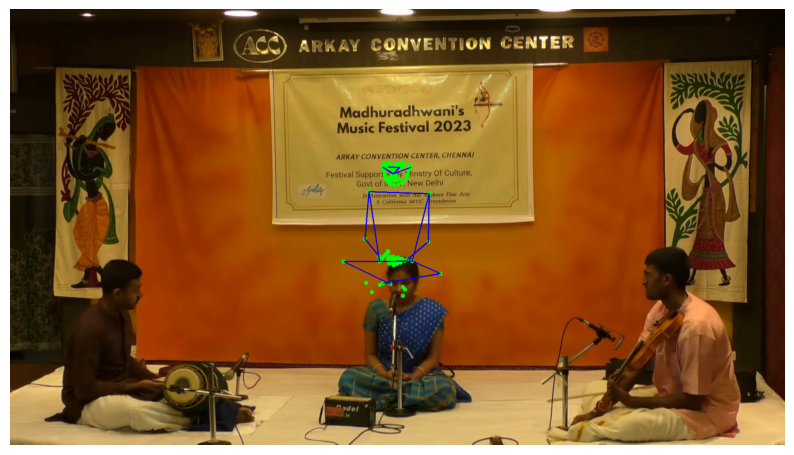

In [19]:
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))  # Frames per second
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

for i in range(np.random.randint(20)):
    ret, frame = cap.read()
    frame_idx = i
    
# Get keypoints and scores for the current frame
if frame_idx < len(keypoints):
    frame_keypoints = keypoints[frame_idx]
    frame_scores = scores[frame_idx]

    # Draw keypoints and skeleton
    for i, (x, y) in enumerate(frame_keypoints):
        # Only draw if confidence score is above threshold
        if frame_scores[i] > 0.5:  # Adjust threshold as needed
            cv2.circle(frame, (int(x + frame_width / 2), int(y + frame_height / 2)), 5, (0, 255, 0), -1)

    # Draw skeleton
    for connection in skeleton:
        start, end = connection
        if frame_scores[start] > 0.5 and frame_scores[end] > 0.5:
            x1, y1 = frame_keypoints[start]
            x2, y2 = frame_keypoints[end]

            # Even though the keypoints are normalized to origin (0, 0), to draw the skeletion at the center of the image, 
            # you will have to move the keypoints by height/2 in y axis direction and width/2 in x axis
            x1 += frame_width / 2
            x2 += frame_width / 2
            y1 += frame_height / 2
            y2 += frame_height / 2
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
            
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()